# Slide 1: Customer Segmentation for Strategic Sales Management

**Technical Presentation**  

Prepared by Bir Bikram Biswasray

# Slide 2: Problem Framing

**Objective:** To segment wholesale customers into distinct groups based on annual spending patterns across six product categories.

*   **Goal:** Enable targeted marketing strategies and operational improvements.
*   **Business Question:** Can we identify high-value retail vs. restaurant segments to optimize supply chain and promotion efforts?

# Slide 3: Dataset Overview

**Dataset Source:** UCI Machine Learning Repository (Wholesale Customers Dataset)

*   **Size:** 440 Clients
*   **Spending Categories:** Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen.
*   **Demographics:** Includes Channel (Horeca/Retail) and Region (Lisbon/Oporto/Other) as metadata.

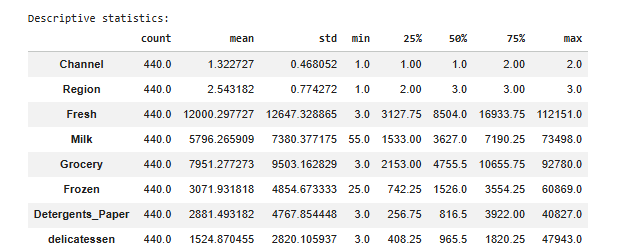

# Slide 4: Preprocessing and Feature Engineering

**Data Preparation Pipeline:**

1.  **Log Transformation:** Applied `np.log1p` to mitigate heavy right-skewness in spending data.
2.  **Feature Scaling:** Standardized data using `StandardScaler` to ensure all spending categories contribute equally to the distance metrics.
3.  **Validation:** Verified no missing values or negative spending records.

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler

features = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

X = df[features]

# Reduce skewness
X_log = np.log1p(X)

# Standardise features
X_scaled = StandardScaler().fit_transform(X_log)

# Validate data quality
print("Missing values:", df.isnull().sum().sum())
print("Negative values:", (X < 0).sum().sum())


Spending-value validation:


,Negative Values,Zero Values
Fresh,0,0
Milk,0,0
Grocery,0,0
Frozen,0,0
Detergents_Paper,0,0
Delicassen,0,0


# Slide 5: Exploratory Data Analysis

**Key Findings:**

*   Strong correlations observed between **Milk, Grocery, and Detergents_Paper**, indicating these are often purchased together.
*   Fresh and Frozen spending show distinct distribution patterns compared to shelf-stable goods.

In [ ]:
# Correlation analysis
correlation_matrix = df_clean[spending_columns].corr()

plt.figure(figsize=(7, 5))
plt.imshow(correlation_matrix)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(spending_columns)),
    spending_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spending_columns)),
    spending_columns
)

plt.title("Correlation Between Spending Categories")
plt.tight_layout()
plt.show()

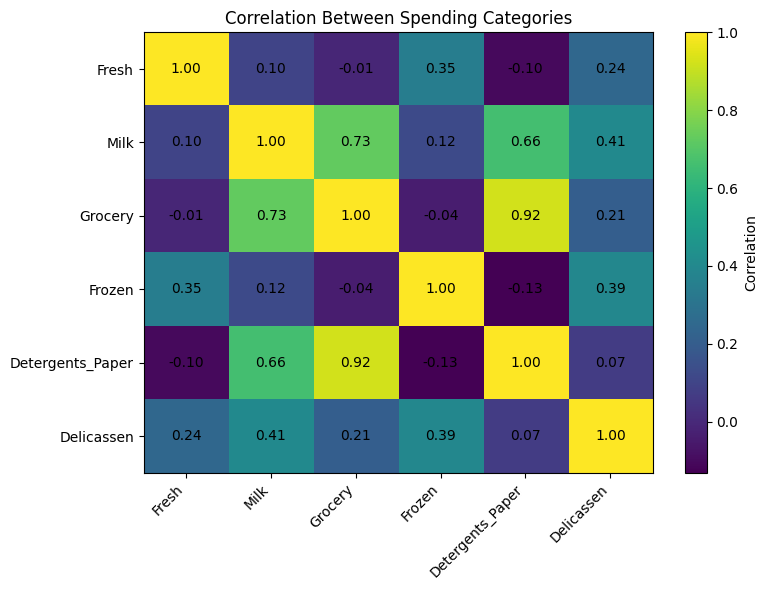

# Slide 6: PCA and Dimensionality Reduction

**Reducing Complexity:**

*   **Variance Explained:** The first two Principal Components (PC1 and PC2) capture a significant portion of the spending variance.
*   **Visual Insight:** PCA projection reveals natural separation in customer behavior even before formal clustering.

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Reduce six spending features to two components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(
    "Variance explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Wholesale Customers")
plt.tight_layout()
plt.show()

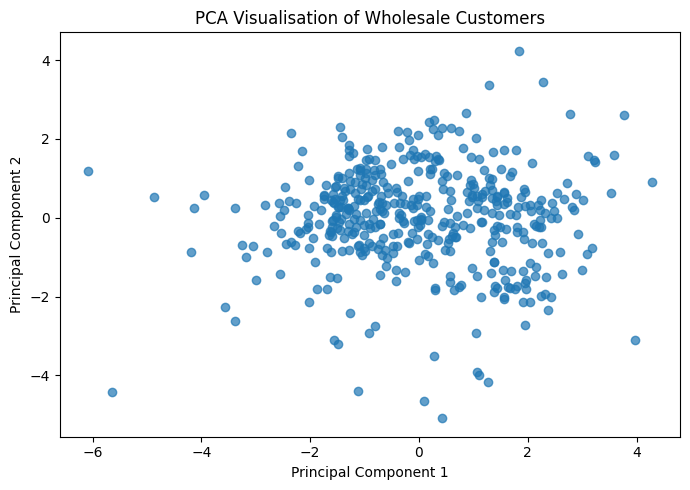

In [ ]:
#Check if pca_df exists, otherwise recreate it from X_scaled
try:
    _ = pca_df
except NameError:
    pca_2d = PCA(n_components=2)
    X_pca = pca_2d.fit_transform(X_scaled)
    pca_df = pd.DataFrame(
        X_pca,
        columns=["PC1", "PC2"],
        index=range(len(X_pca))
    )

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Clusters (PCA Projection)")
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()

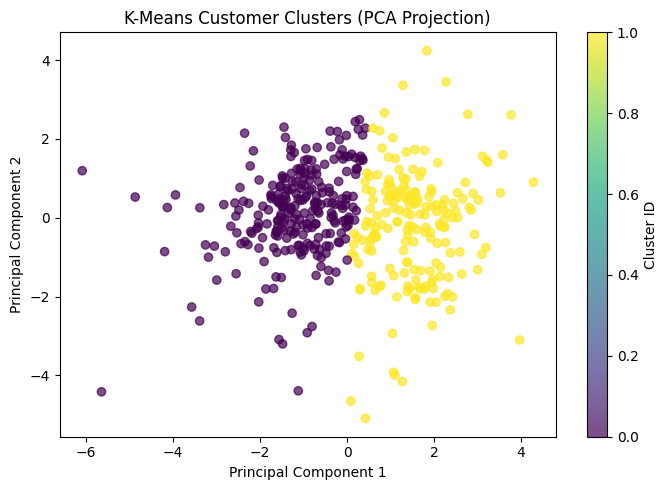

# Slide 7: Clustering Models

**The K-Means Approach:**

*   **Optimal K:** Evaluation via Silhouette scores and the Elbow method indicated **K=2** as the most stable configuration.
*   **Segments:** Successfully partitioned 440 customers into two primary clusters.

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Reduce six spending features to two components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(
    "Variance explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Wholesale Customers")
plt.tight_layout()
plt.show()

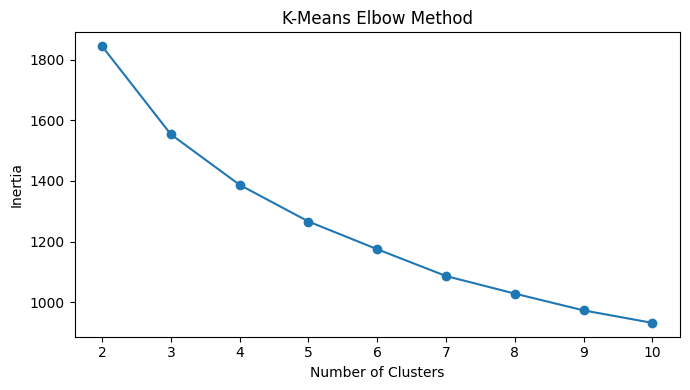

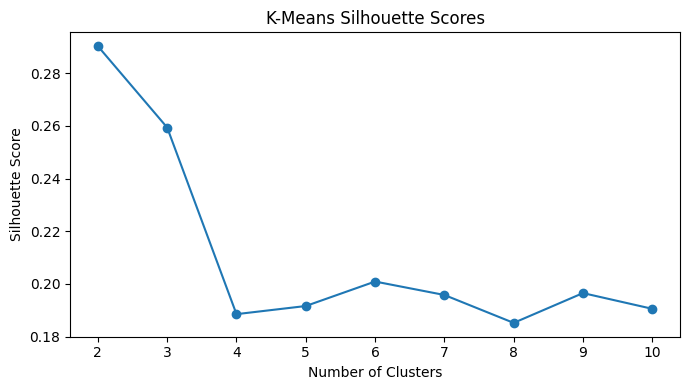

Best K based on Silhouette Score: 2

Cluster sizes:

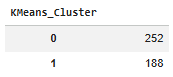



# Slide 8: Model Comparison and Final Selection

**Final Model Selection:**

*   **Segment 0 (Horeca-Style):** High median spending on **Fresh** and **Frozen** products. Represents Hotels, Restaurants, and Cafes.
*   **Segment 1 (Retail-Style):** Dominated by **Grocery**, **Milk**, and **Detergents_Paper** spending. Represents Retail outlets and supermarkets.

In [ ]:
from sklearn.cluster import KMeans

features = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

# Final K-Means model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Interpret cluster profiles
profiles = df.groupby("Cluster")[features].median()
display(profiles)

| Model        |     Silhouette | Davies–Bouldin | Calinski–Harabasz | Outcome                        |
| ------------ | -------------: | -------------: | ----------------: | ------------------------------ |
| K-Means      |          0.290 |          1.352 |           189.050 | Selected                       |
| Hierarchical |          0.258 |          1.600 |           134.624 | Second-best                    |
| DBSCAN       | Not comparable |              — |                 — | Excessive noise or one cluster |


# Slide 9: Explainability, Fairness and Limitations

**Model Interpretability:**

*   **SHAP Analysis:** Confirms that **Detergents_Paper, Milk** and **Grocery** are the top predictors for Segment 1 classification.

*   **Fairness:** Channel had a strong association with segment membership, while Region showed minimal influence.

*   **Limitations:** Analysis relies on monetary volume; seasonality and purchase frequency were not captured in this dataset.

In [ ]:
# Explain Cluster 1 using SHAP
explainer = shap.Explainer(surrogate_model, X_train)
shap_values = explainer(X_test)

shap_cluster_1 = shap_values[:, :, 1]

# Global feature importance
shap.plots.bar(shap_cluster_1, max_display=6)

# Direction of feature influence
shap.plots.beeswarm(shap_cluster_1, max_display=6)

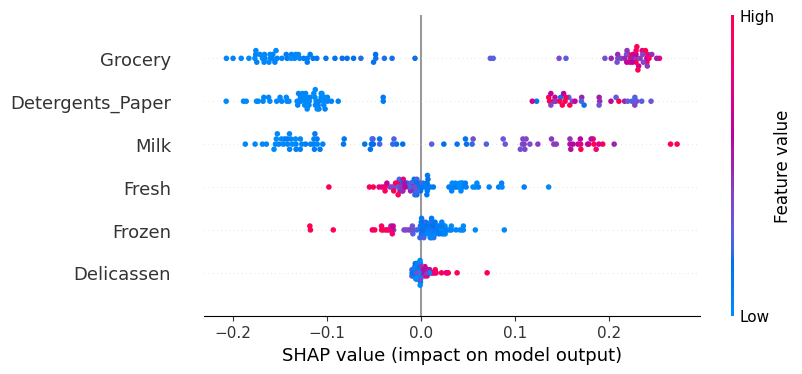

# Slide 10: Conclusions and Recommendations

**Strategic Actions:**

1.  **Tailored Promotions:** Target Segment 1 with bundled offers on non-perishables (Grocery/Detergents).
2.  **Supply Chain Optimization:** Prioritize cold-chain logistics for Segment 0 (Fresh/Frozen).
3.  **Expansion:** Use the surrogate model logic to classify new incoming leads based on their initial purchase intent.